# Customer Churn Analysis and Retention Strategy
**Author:** Sanman Kadam  
**Status:** Complete  
**License:** MIT  

---

## 1. Business Problem
A telecom company operating across major regional circles in India is experiencing customer attrition (churn), leading to substantial revenue loss and increased subscriber acquisition costs. In the highly competitive Indian telecom market, retaining high-value subscribers is critical for maintaining market share and profitability.

The objective of this project is to analyze historical subscriber data, identify key drivers of customer churn, segment regional circles based on risk and revenue value, and build machine learning models to predict subscriber decline at a circle level. These insights will drive action-oriented retention strategies with quantifiable business impact.

## 2. Project Objectives
- **Descriptive Analysis:** Understand subscriber trends and regional differences across circles.
- **Revenue Risk Mapping:** Quantify the financial impact of subscriber attrition across different regions and connection types.
- **Risk Segmentation:** Categorize circles into risk tiers (Low, Medium, High, Critical) using a composite risk score.
- **Predictive Modeling:** Train and evaluate classification models (Logistic Regression, Random Forest, Decision Trees, etc.) to predict subscriber decline.
- **Strategic Recommendations:** Propose specific, ROI-backed actions to minimize churn and protect revenue.

---


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
import os
paths = ["Telecom_Features.csv", "notebooks/Telecom_Features.csv", "../data/Telecom_Features.csv", "data/Telecom_Features.csv"]
for path in paths:
    if os.path.exists(path):
        df = pd.read_csv(path)
        break


FileNotFoundError: [Errno 2] No such file or directory: '/Users/the_irritater/Projects/customer-churn-analysis-dashboard/data/Cleaned_Telecom_Subscriptions.csv.csv'

In [ ]:
df.head()

,year,month,circle,type_of_connection,service_provider,value,month_num,date,subscribers_lag_1,subscribers_lag_3,...,trend_12m,total_circle_subscribers,market_share,market_rank,share_gap_leader,relative_performance,circle_type,is_wireless,market_size_category,operator_geographic_diversity
0,2025,April,Andhra Pradesh,wireless,Bharti Airtel (Including Tata Tele.),33965795.0,4,2025-04-01,0.0,0.0,...,0.0,86754693.0,0.391515,1.0,0.000000,6.264246,Non-Metro,1.0,1.481718e+10,23.0
1,2025,April,Assam,wireless,Bharti Airtel (Including Tata Tele.),12314102.0,4,2025-04-01,0.0,0.0,...,0.0,26794099.0,0.459583,1.0,0.000000,7.353322,Non-Metro,1.0,3.819044e+09,23.0
2,2025,April,Bihar,wireless,Bharti Airtel (Including Tata Tele.),40967773.0,4,2025-04-01,0.0,0.0,...,0.0,97994908.0,0.418060,2.0,0.011617,6.688964,Non-Metro,1.0,1.457673e+10,23.0
3,2025,April,Delhi,wireless,Bharti Airtel (Including Tata Tele.),18877637.0,4,2025-04-01,0.0,0.0,...,0.0,63457000.0,0.297487,2.0,0.015992,4.759793,Metro,1.0,9.914558e+09,23.0
4,2025,April,Gujarat,wireless,Bharti Airtel (Including Tata Tele.),12401101.0,4,2025-04-01,0.0,0.0,...,0.0,67527862.0,0.183644,3.0,0.267338,2.938307,Non-Metro,1.0,1.214509e+10,23.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38385 entries, 0 to 38384
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   year                           38385 non-null  int64  
 1   month                          38385 non-null  object 
 2   circle                         38385 non-null  object 
 3   type_of_connection             38385 non-null  object 
 4   service_provider               38385 non-null  object 
 5   value                          38385 non-null  float64
 6   month_num                      38385 non-null  int64  
 7   date                           38385 non-null  object 
 8   subscribers_lag_1              38385 non-null  float64
 9   subscribers_lag_3              38385 non-null  float64
 10  subscribers_lag_6              38385 non-null  float64
 11  subscribers_lag_12             38385 non-null  float64
 12  mom_growth                     38385 non-null 

In [ ]:
df.describe()

,year,value,month_num,subscribers_lag_1,subscribers_lag_3,subscribers_lag_6,subscribers_lag_12,mom_growth,yoy_growth,growth_volatility_3,...,growth_volatility_12,trend_12m,total_circle_subscribers,market_share,market_rank,share_gap_leader,relative_performance,is_wireless,market_size_category,operator_geographic_diversity
count,38385.000000,3.838500e+04,38385.000000,3.838500e+04,3.838500e+04,3.838500e+04,3.838500e+04,3.838500e+04,3.838400e+04,38384.000000,...,38384.000000,3.838400e+04,3.838400e+04,38384.000000,38384.000000,38384.000000,38384.000000,38384.0,3.838400e+04,38384.000000
mean,2016.664765,9.390211e+06,6.534584,9.261111e+06,9.058495e+06,8.749464e+06,8.115159e+06,inf,inf,5.462343,...,9.581274,-1.907432e+04,9.353160e+07,0.097854,7.211872,0.203702,1.451911,1.0,1.732398e+10,28.671373
std,3.990356,3.389596e+07,3.437907,3.360546e+07,3.330137e+07,3.283724e+07,3.188812e+07,NaN,NaN,490.964339,...,487.954929,4.398317e+05,2.135842e+08,0.116838,5.245873,0.129237,1.694465,0.0,3.957401e+10,4.312925
min,2011.000000,0.000000e+00,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+00,-1.000000e+00,0.000000,...,0.000000,-1.368269e+07,5.845936e+06,0.000000,0.000000,0.000000,0.000000,1.0,1.143634e+09,23.000000
25%,2013.000000,0.000000e+00,4.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-6.973639e-03,-4.452745e-02,0.000000,...,0.000000,-1.596958e+04,2.686425e+07,0.000000,3.000000,0.103053,0.000000,1.0,4.902666e+09,24.000000
50%,2016.000000,2.013914e+06,7.000000,1.893103e+06,1.690250e+06,1.422240e+06,7.569550e+05,0.000000e+00,0.000000e+00,0.003260,...,0.004935,0.000000e+00,5.142423e+07,0.057583,6.000000,0.212920,0.864869,1.0,9.786751e+09,30.000000
75%,2020.000000,7.247179e+06,10.000000,7.145249e+06,6.996873e+06,6.747231e+06,6.230390e+06,8.364461e-04,1.606890e-02,0.011447,...,0.016077,1.250490e+02,7.163821e+07,0.161347,11.500000,0.296467,2.454080,1.0,1.270691e+10,32.000000
max,2025.000000,4.765272e+08,12.000000,4.765272e+08,4.765272e+08,4.765272e+08,4.765272e+08,inf,inf,55052.955885,...,27526.355620,1.368338e+07,2.295845e+09,0.811648,22.500000,0.811648,10.551425,1.0,2.021965e+11,36.000000


In [ ]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Check top rows and data info
print(df.head())
print(df.info())

   year  month          circle type_of_connection  \
0  2025  April  Andhra Pradesh           wireless   
1  2025  April           Assam           wireless   
2  2025  April           Bihar           wireless   
3  2025  April           Delhi           wireless   
4  2025  April         Gujarat           wireless   

                       service_provider       value  month_num        date  \
0  Bharti Airtel (Including Tata Tele.)  33965795.0          4  2025-04-01   
1  Bharti Airtel (Including Tata Tele.)  12314102.0          4  2025-04-01   
2  Bharti Airtel (Including Tata Tele.)  40967773.0          4  2025-04-01   
3  Bharti Airtel (Including Tata Tele.)  18877637.0          4  2025-04-01   
4  Bharti Airtel (Including Tata Tele.)  12401101.0          4  2025-04-01   

   subscribers_lag_1  subscribers_lag_3  ...  trend_12m  \
0                0.0                0.0  ...        0.0   
1                0.0                0.0  ...        0.0   
2                0.0               

In [ ]:
# Numeric summary
numeric_cols = df.select_dtypes(include=np.number).columns
print(df[numeric_cols].describe().T)

# Count of missing values
print(df.isna().sum())

# Unique values in key categorical columns
print(df['service_provider'].nunique(), df['circle'].nunique())


                                 count          mean           std  \
year                           38385.0  2.016665e+03  3.990356e+00   
value                          38385.0  9.390211e+06  3.389596e+07   
month_num                      38385.0  6.534584e+00  3.437907e+00   
subscribers_lag_1              38385.0  9.261111e+06  3.360546e+07   
subscribers_lag_3              38385.0  9.058495e+06  3.330137e+07   
subscribers_lag_6              38385.0  8.749464e+06  3.283724e+07   
subscribers_lag_12             38385.0  8.115159e+06  3.188812e+07   
mom_growth                     38253.0  3.168529e+00  4.918253e+02   
yoy_growth                     37499.0  1.093898e+02  5.905970e+03   
growth_volatility_3            38384.0  5.462343e+00  4.909643e+02   
growth_volatility_6            38384.0  7.198995e+00  4.892046e+02   
growth_volatility_12           38384.0  9.581274e+00  4.879549e+02   
trend_12m                      38384.0 -1.907432e+04  4.398317e+05   
total_circle_subscri

In [ ]:
# Fill missing growth values with median (more realistic)
df['mom_growth'] = df['mom_growth'].fillna(df['mom_growth'].median())
df['yoy_growth'] = df['yoy_growth'].fillna(df['yoy_growth'].median())

In [ ]:
# Check missing values
print("Missing values after cleaning:\n", df.isna().sum())

Missing values after cleaning:
 year                             0
month                            0
circle                           0
type_of_connection               0
service_provider                 0
value                            0
month_num                        0
date                             0
subscribers_lag_1                0
subscribers_lag_3                0
subscribers_lag_6                0
subscribers_lag_12               0
mom_growth                       0
yoy_growth                       0
growth_volatility_3              1
growth_volatility_6              1
growth_volatility_12             1
trend_12m                        1
total_circle_subscribers         1
market_share                     1
market_rank                      1
share_gap_leader                 1
relative_performance             1
circle_type                      1
is_wireless                      1
market_size_category             1
operator_geographic_diversity    1
dtype: int64


In [ ]:
# -----------------------
# Numeric Summary
# -----------------------
numeric_cols = df.select_dtypes(include=np.number).columns
print("\nNumeric Summary:\n", df[numeric_cols].describe().T)


Numeric Summary:
                                  count          mean           std  \
year                           38385.0  2.016665e+03  3.990356e+00   
value                          38385.0  9.390211e+06  3.389596e+07   
month_num                      38385.0  6.534584e+00  3.437907e+00   
subscribers_lag_1              38385.0  9.261111e+06  3.360546e+07   
subscribers_lag_3              38385.0  9.058495e+06  3.330137e+07   
subscribers_lag_6              38385.0  8.749464e+06  3.283724e+07   
subscribers_lag_12             38385.0  8.115159e+06  3.188812e+07   
mom_growth                     38385.0  3.157633e+00  4.909789e+02   
yoy_growth                     38385.0  1.068648e+02  5.837433e+03   
growth_volatility_3            38384.0  5.462343e+00  4.909643e+02   
growth_volatility_6            38384.0  7.198995e+00  4.892046e+02   
growth_volatility_12           38384.0  9.581274e+00  4.879549e+02   
trend_12m                      38384.0 -1.907432e+04  4.398317e+05   
t

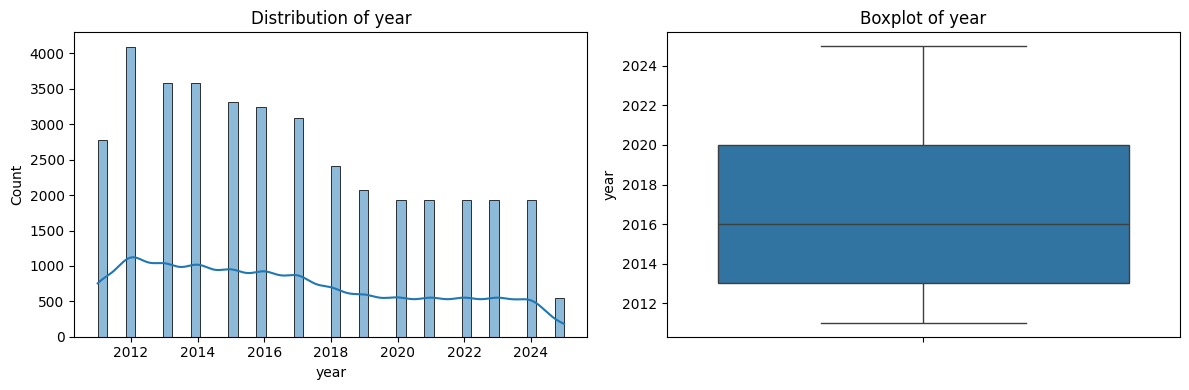

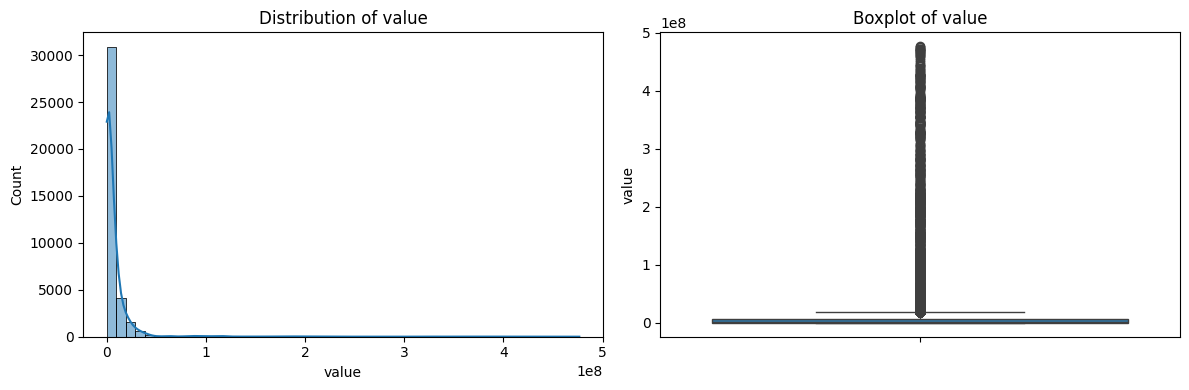

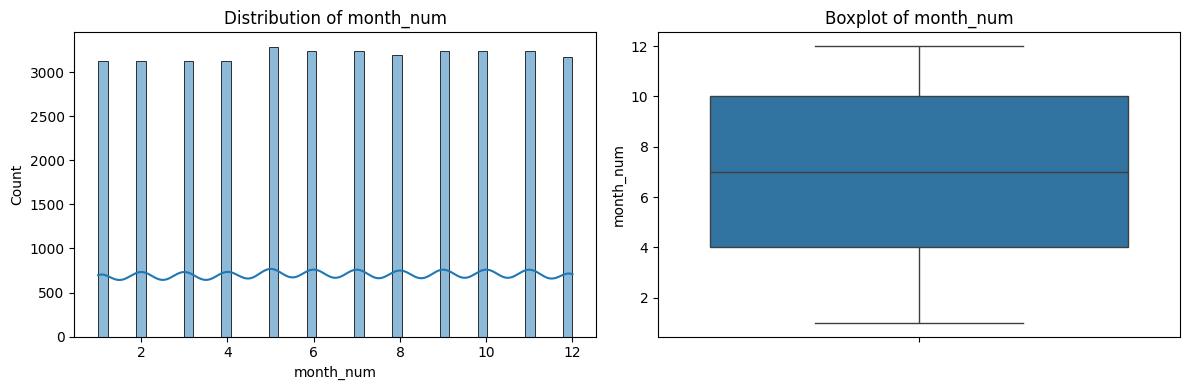

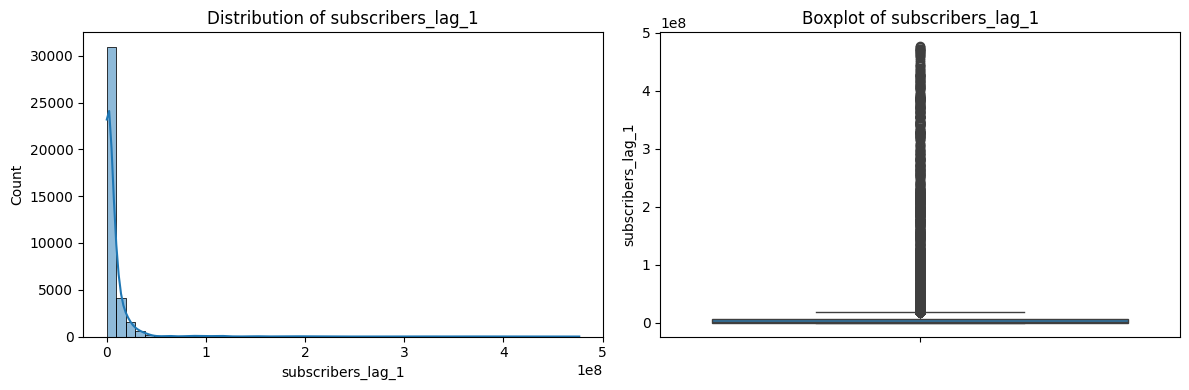

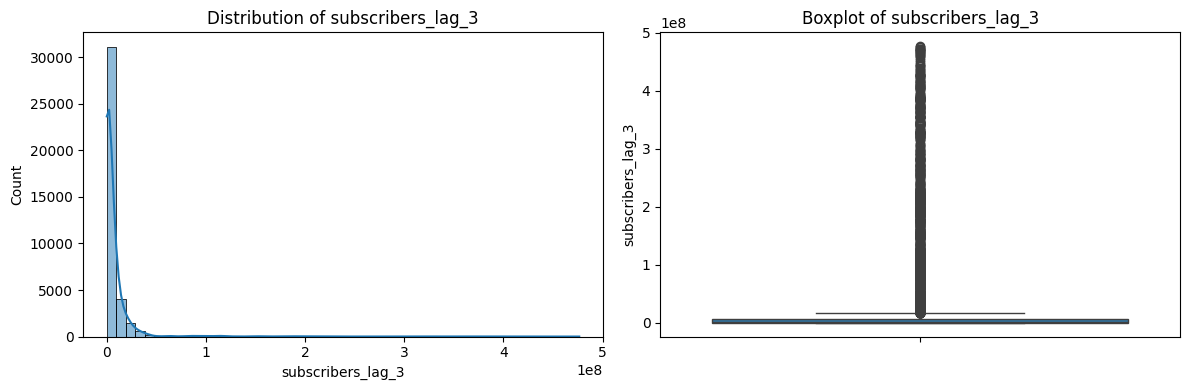

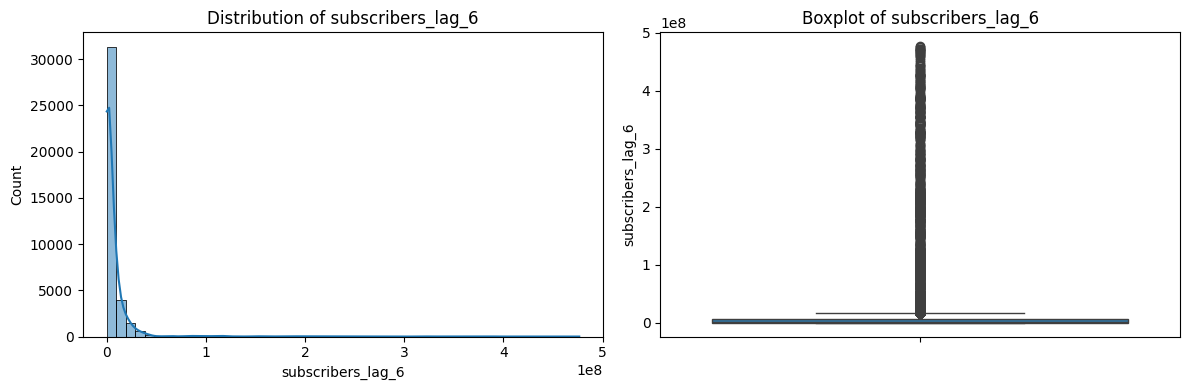

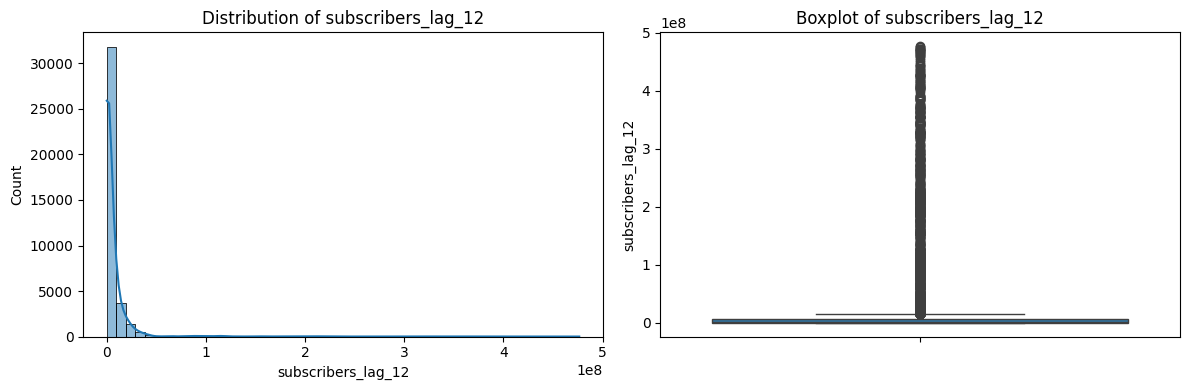

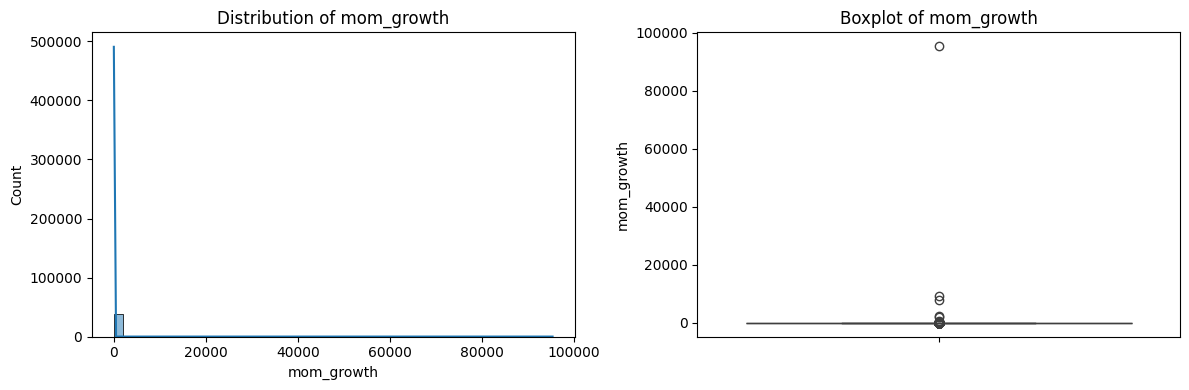

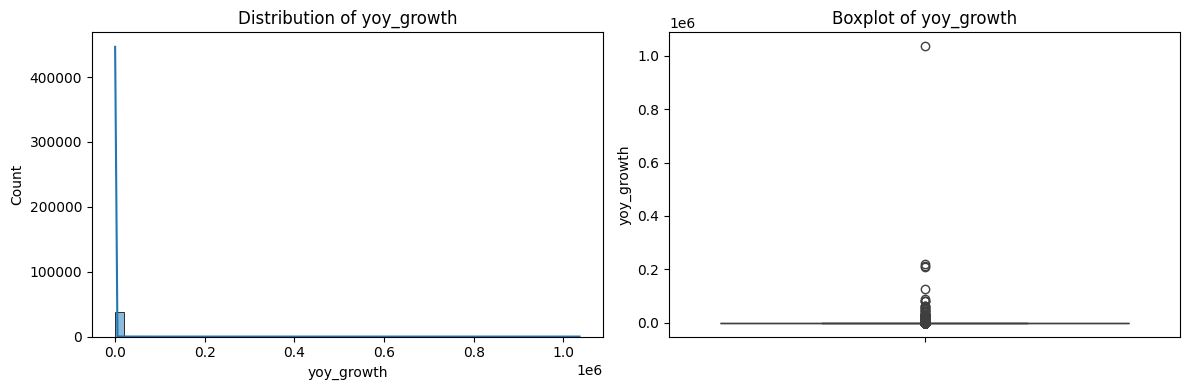

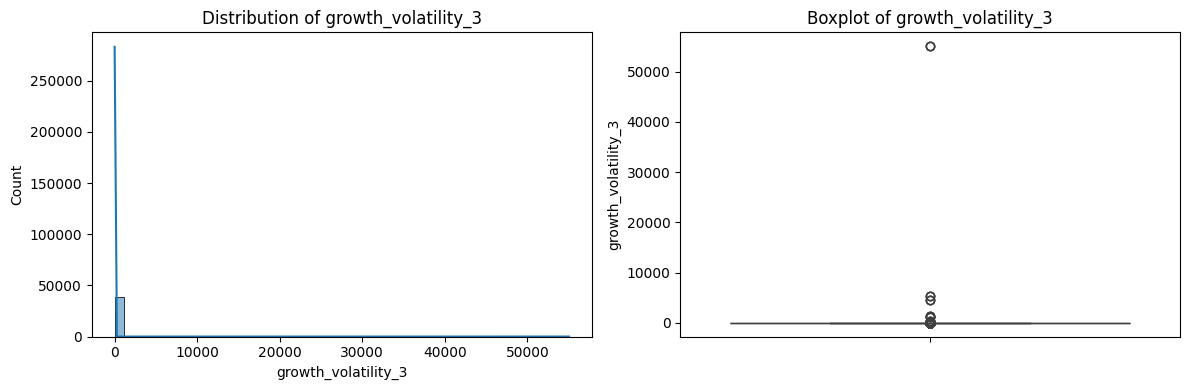

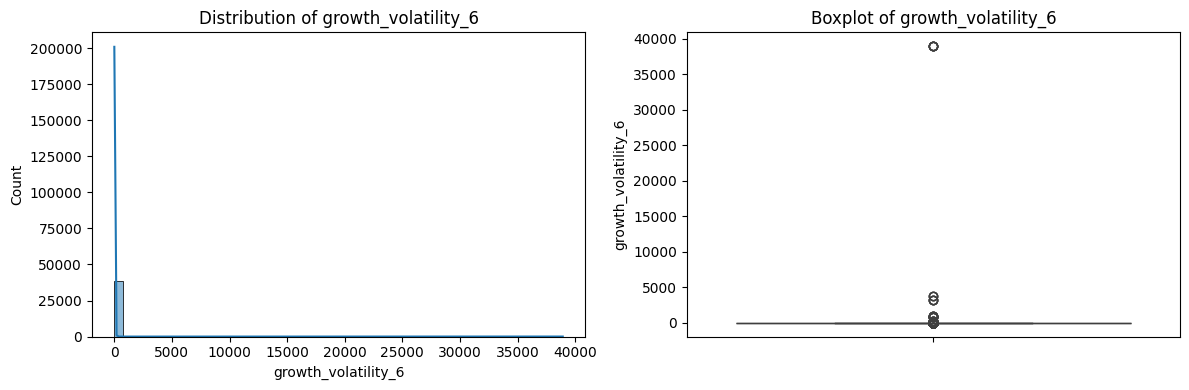

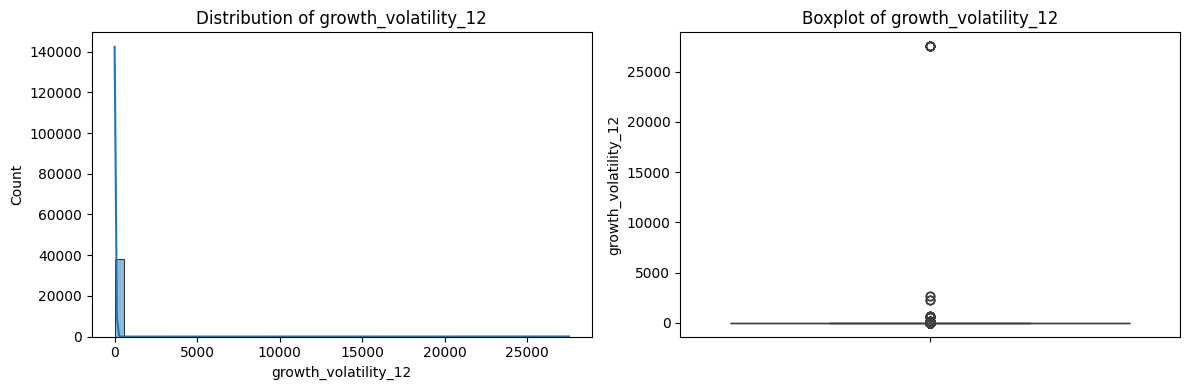

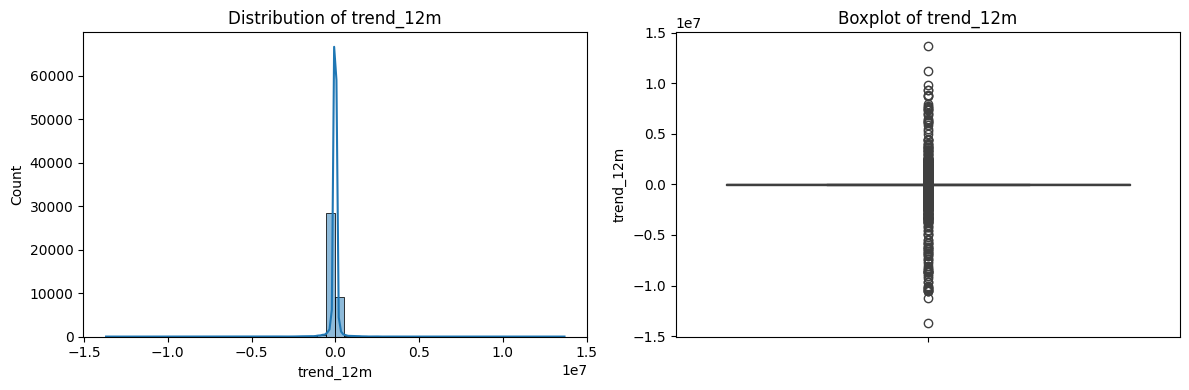

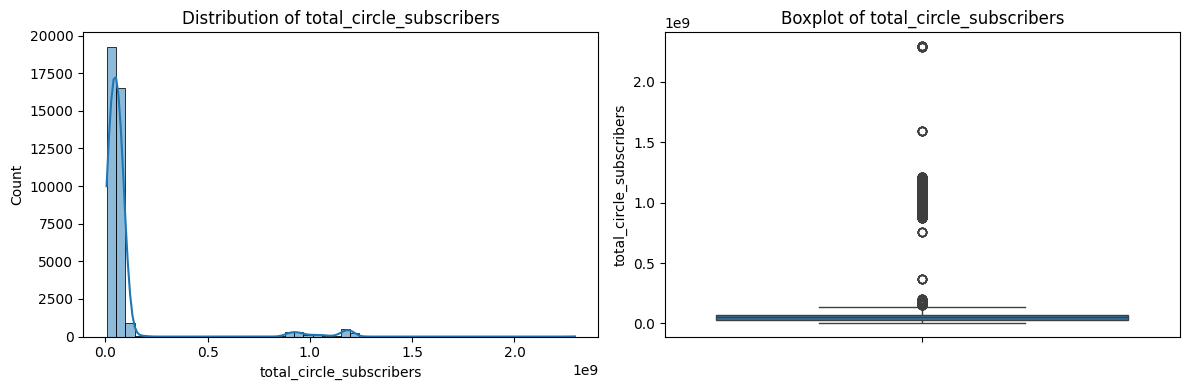

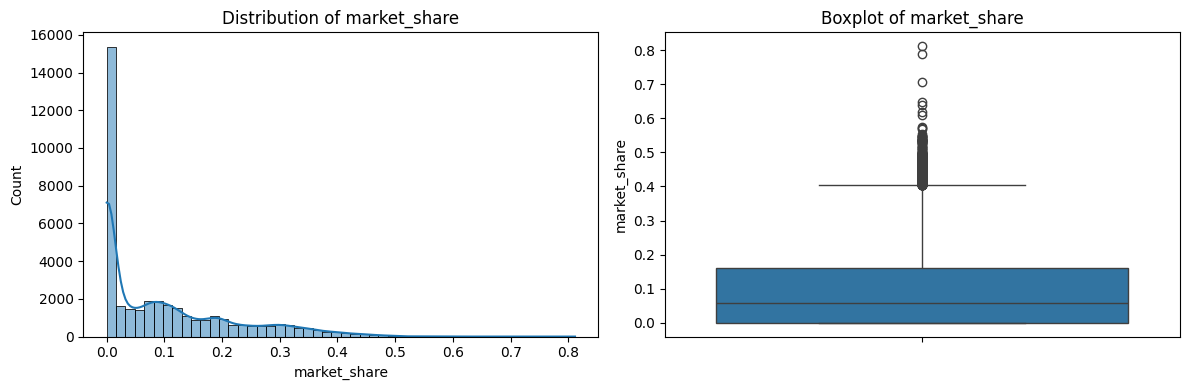

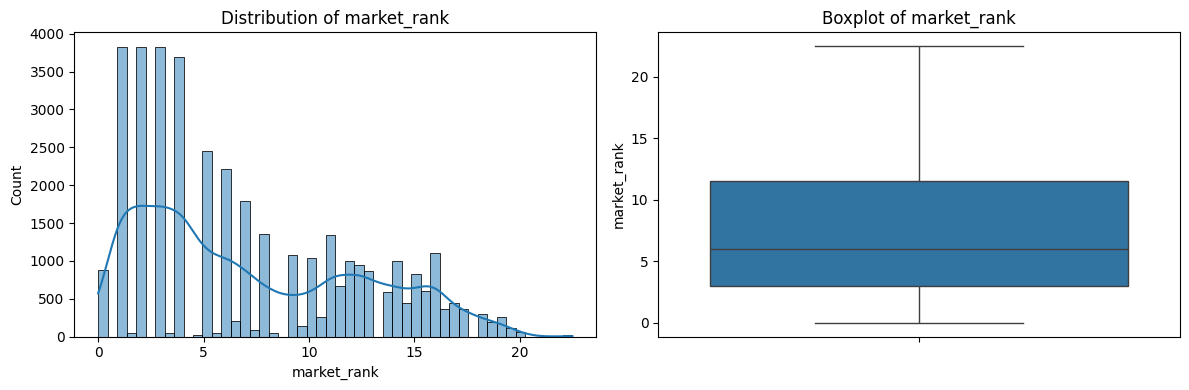

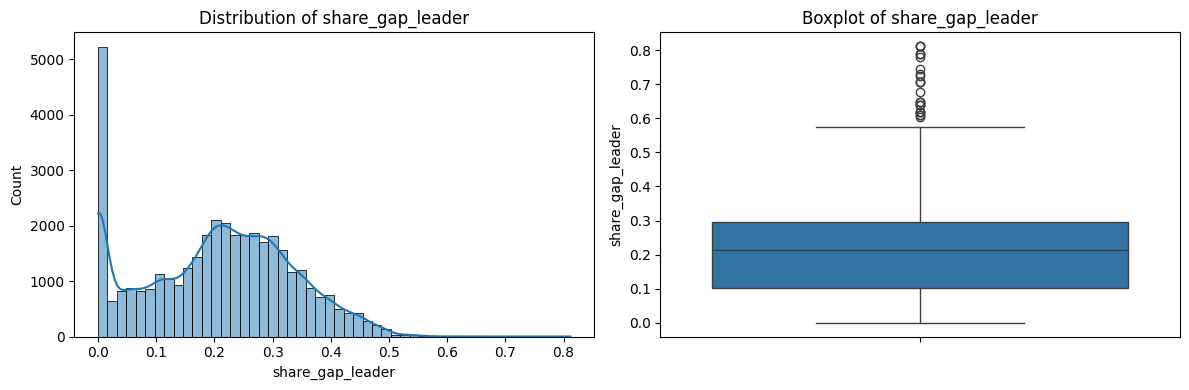

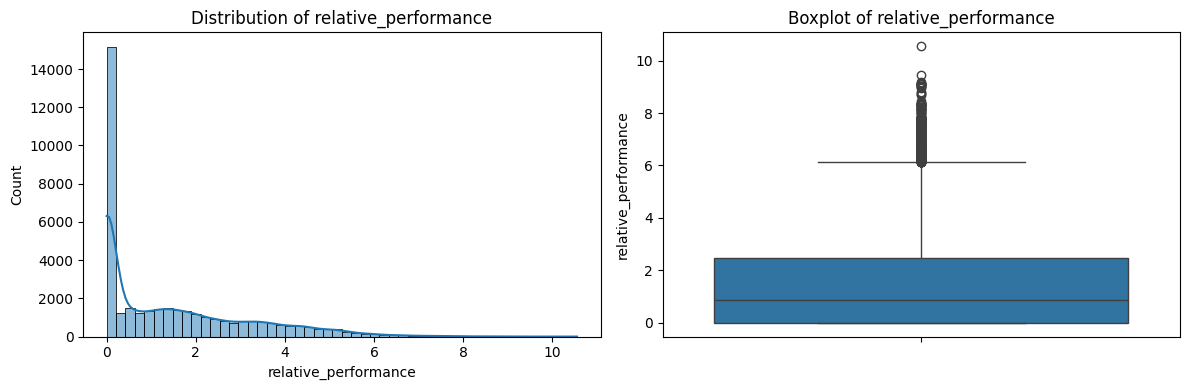

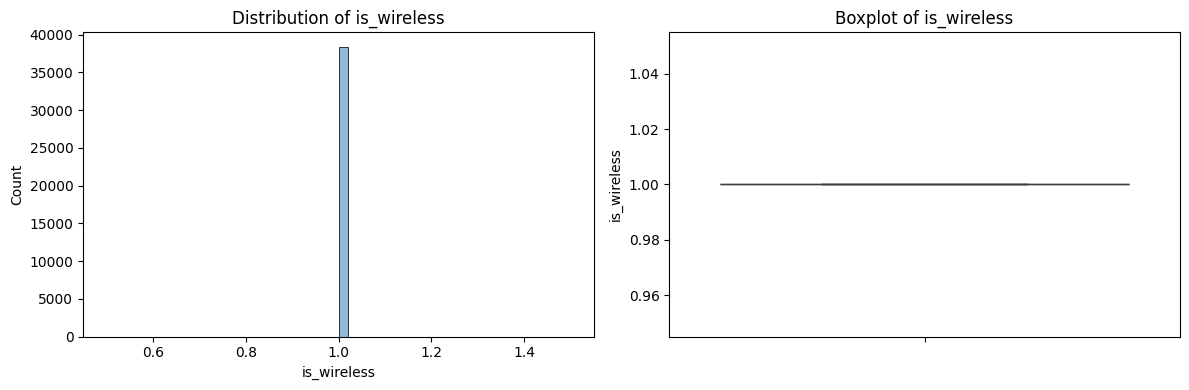

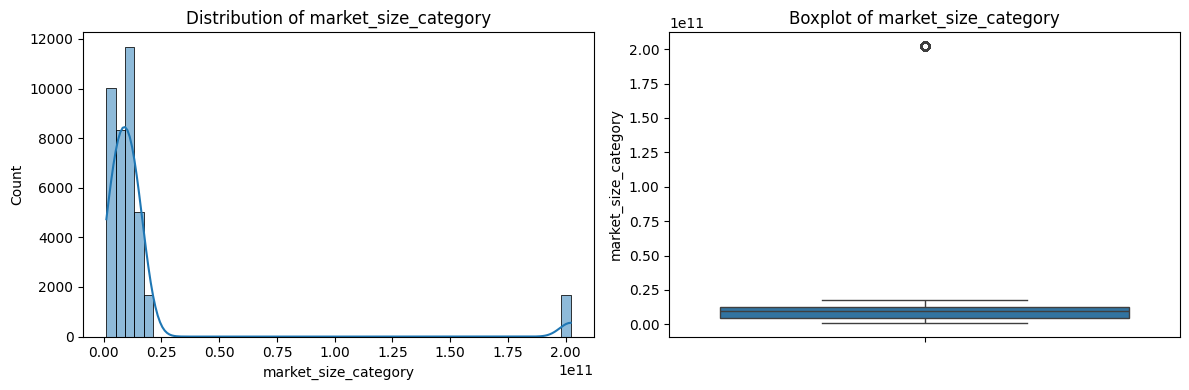

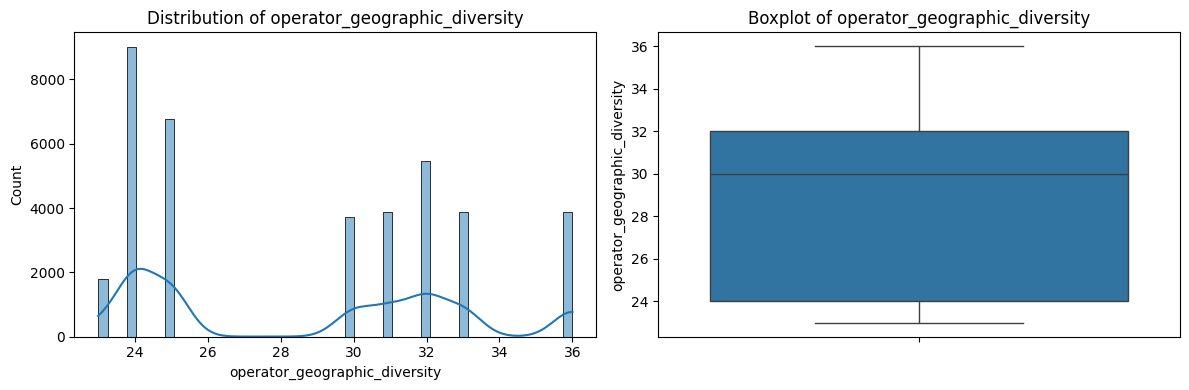

In [ ]:
# -----------------------
#  Univariate Analysis
# -----------------------
for col in numeric_cols:
    plt.figure(figsize=(12,4))

    # Histogram
    plt.subplot(1,2,1)
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f'Distribution of {col}')

    # Boxplot
    plt.subplot(1,2,2)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()


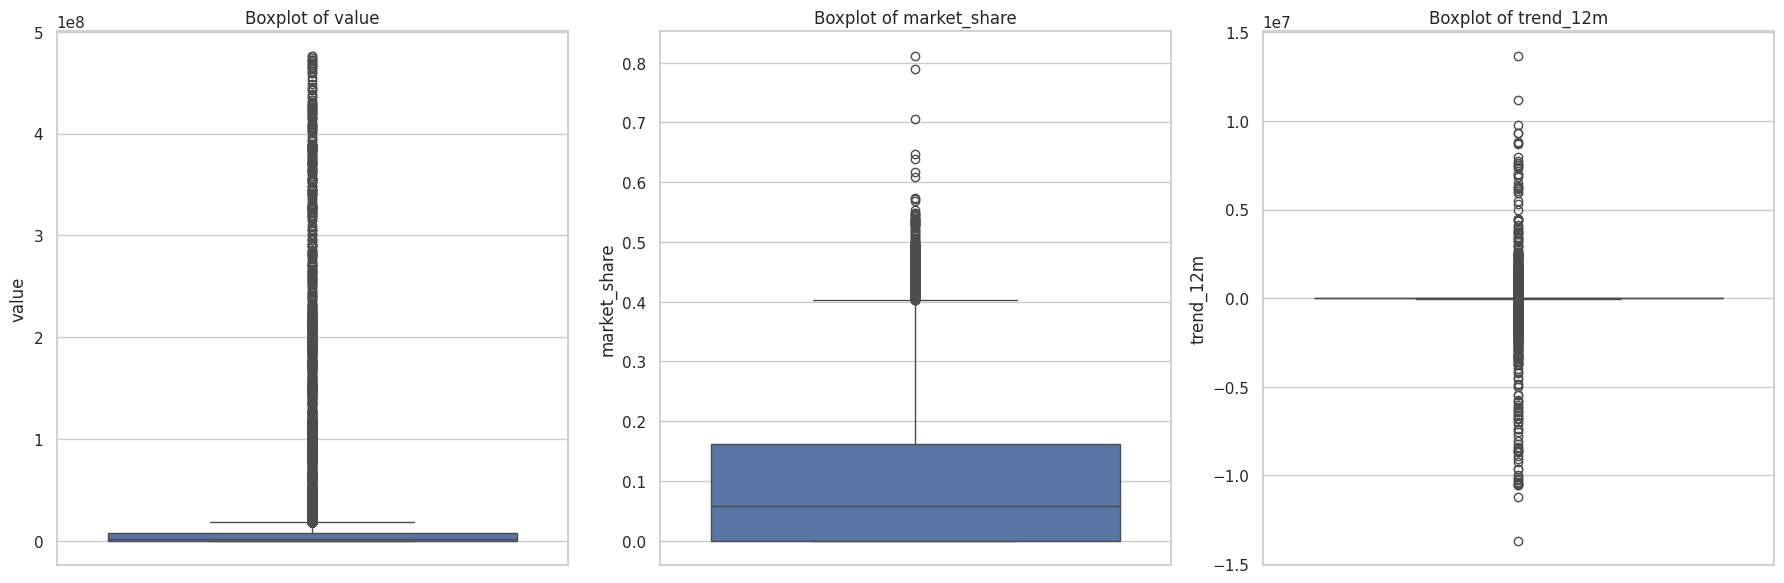

In [ ]:
# Set style
sns.set(style="whitegrid")

# Columns to plot
cols_to_plot = ['value', 'market_share', 'trend_12m']

# Create subplots
plt.figure(figsize=(18, 6))

for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

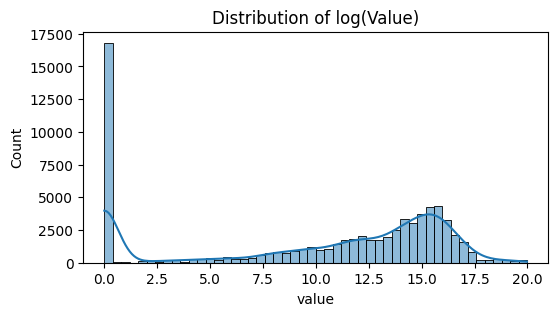

In [ ]:
# For heavily skewed columns like 'value', use log scale
plt.figure(figsize=(6,3))
sns.histplot(np.log1p(df['value']), bins=50, kde=True)
plt.title('Distribution of log(Value)')
plt.show()

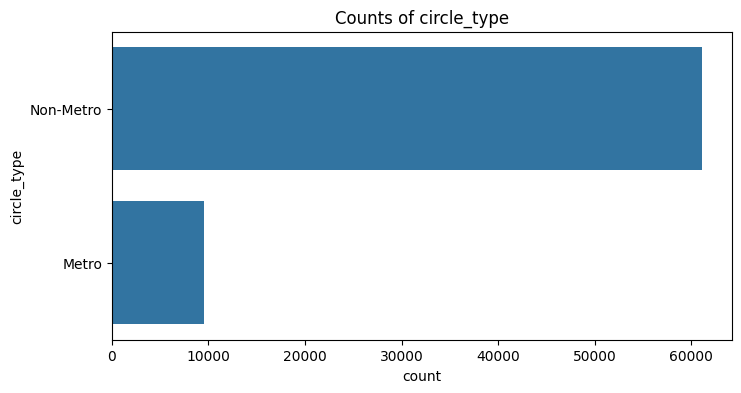

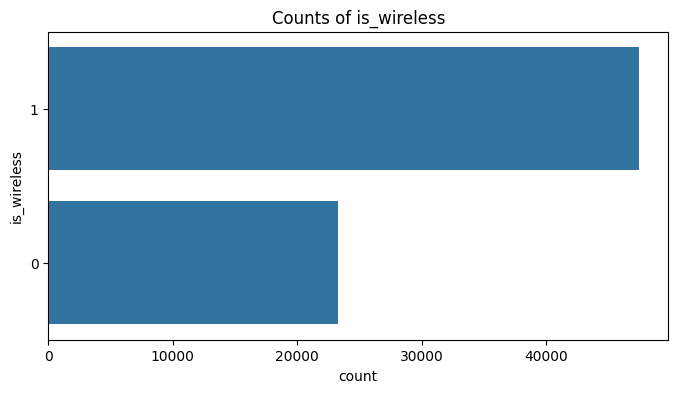

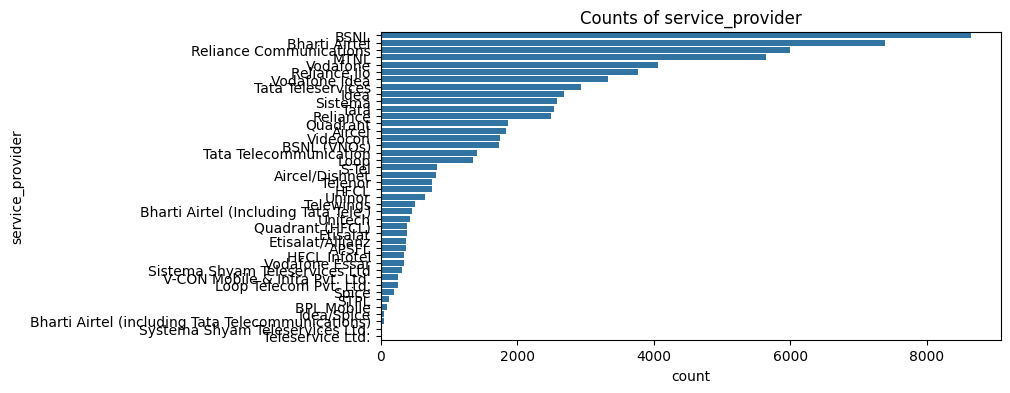

In [ ]:
# -----------------------
# Categorical Columns Analysis
# -----------------------
categorical_cols = ['circle_type', 'is_wireless', 'service_provider']

for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(y=col, data=df, order=df[col].value_counts().index)
    plt.title(f'Counts of {col}')
    plt.show()

In [ ]:
# Unique counts
print("\nUnique values:")
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()}")


Unique values:
circle_type: 2
is_wireless: 2
service_provider: 42


In [ ]:

# -----------------------------
# TIME-BASED ANALYSIS (TOP PROVIDERS)
# -----------------------------

Top 10 providers: ['Bharti Airtel', 'Reliance Jio', 'Vodafone Idea', 'BSNL', 'Vodafone', 'Idea', 'Reliance Communications', 'Bharti Airtel (Including Tata Tele.)', 'Tata Teleservices', 'Aircel']


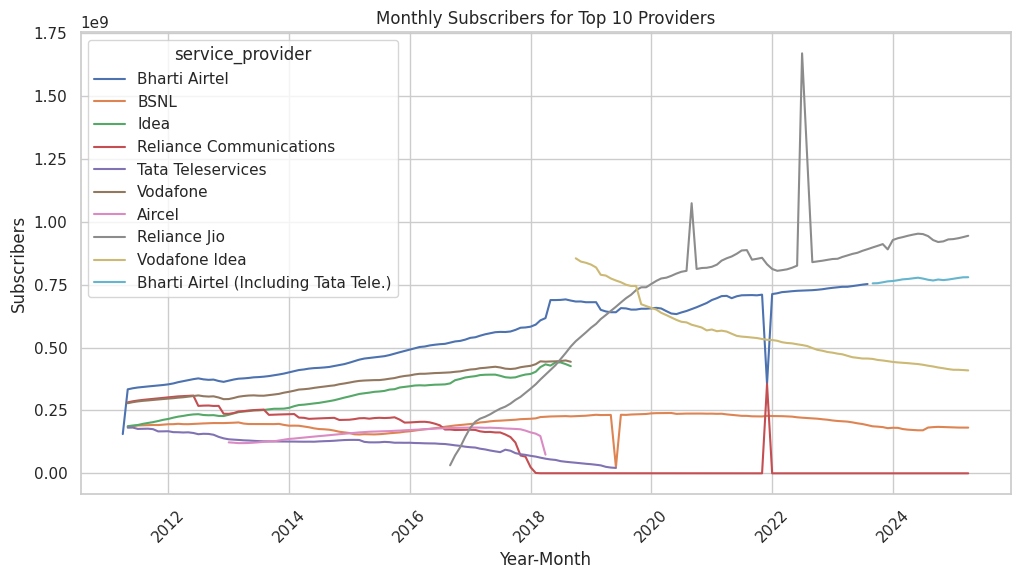

In [ ]:
# Top 10 providers by total subscribers

# Step 1: Create proper datetime column for time-series order
df['year_month'] = pd.to_datetime(df['year'].astype(str) + '-' + df['month_num'].astype(str) + '-01')

# Step 2: Find top 5 providers
top_10_providers = df.groupby('service_provider')['value'].sum().sort_values(ascending=False).head(10).index.tolist()
print("Top 10 providers:", top_10_providers)

# Step 3: Filter to only those top 5 providers
df_top10 = df[df['service_provider'].isin(top_10_providers)]

# Step 4: Aggregate total subscribers per provider per month
df_agg = df_top10.groupby(['year_month', 'service_provider'])['value'].sum().reset_index()

# Step 5: Plot
plt.figure(figsize=(12,6))
sns.lineplot(data=df_agg, x='year_month', y='value', hue='service_provider')
plt.title('Monthly Subscribers for Top 10 Providers')
plt.xlabel('Year-Month')
plt.ylabel('Subscribers')
plt.xticks(rotation=45)
plt.show()


Top 5 providers: ['Bharti Airtel', 'Reliance Jio', 'Vodafone Idea', 'BSNL', 'Vodafone']


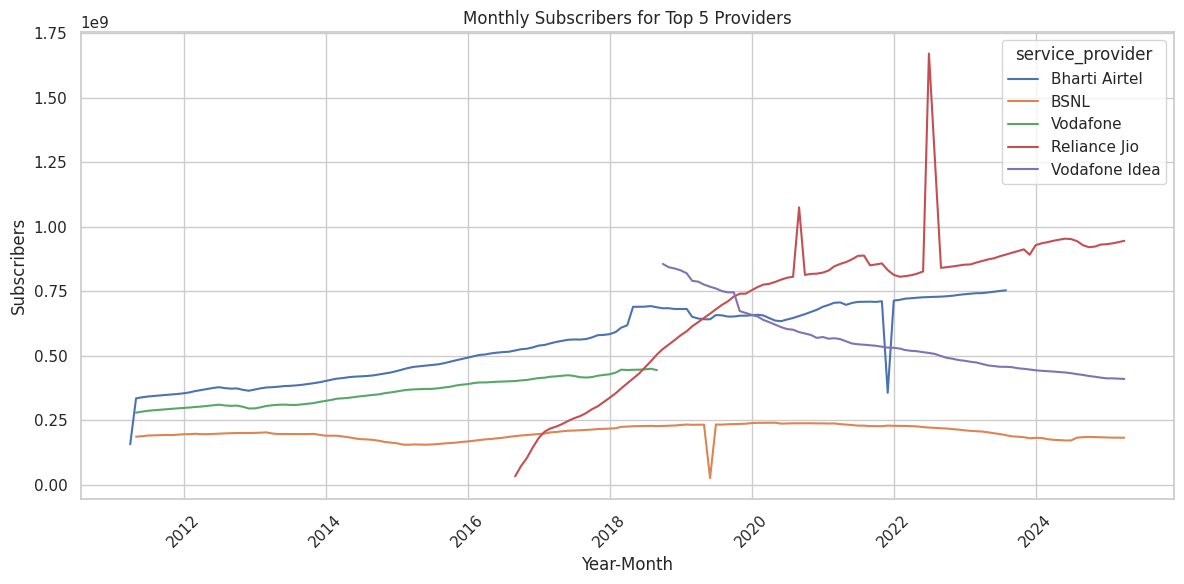

In [ ]:
# Top 15 providers by total subscribers

# Step 1: Create proper datetime column for time-series order
df['year_month'] = pd.to_datetime(df['year'].astype(str) + '-' + df['month_num'].astype(str) + '-01')

# Step 2: Find top 5 providers
top_5_providers = df.groupby('service_provider')['value'].sum().sort_values(ascending=False).head(5).index.tolist()
print("Top 5 providers:", top_5_providers)

# Step 3: Filter to only those top 5 providers
df_top5 = df[df['service_provider'].isin(top_5_providers)]

# Step 4: Aggregate total subscribers per provider per month
df_agg = df_top5.groupby(['year_month', 'service_provider'])['value'].sum().reset_index()

# Step 5: Plot
plt.figure(figsize=(12,6))
sns.lineplot(data=df_agg, x='year_month', y='value', hue='service_provider')
plt.title('Monthly Subscribers for Top 5 Providers')
plt.xlabel('Year-Month')
plt.ylabel('Subscribers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


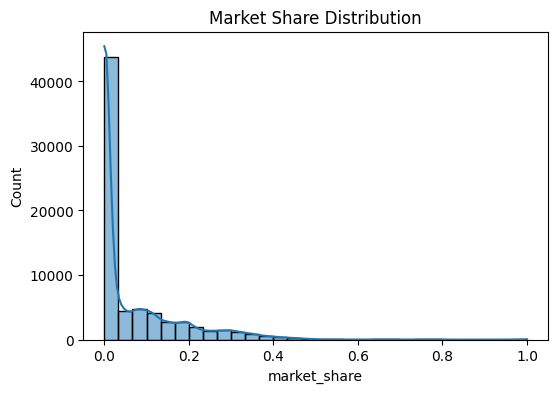

In [ ]:
# Market share distribution

plt.figure(figsize=(6,4))
sns.histplot(df['market_share'], bins=30, kde=True)
plt.title('Market Share Distribution')
plt.show()

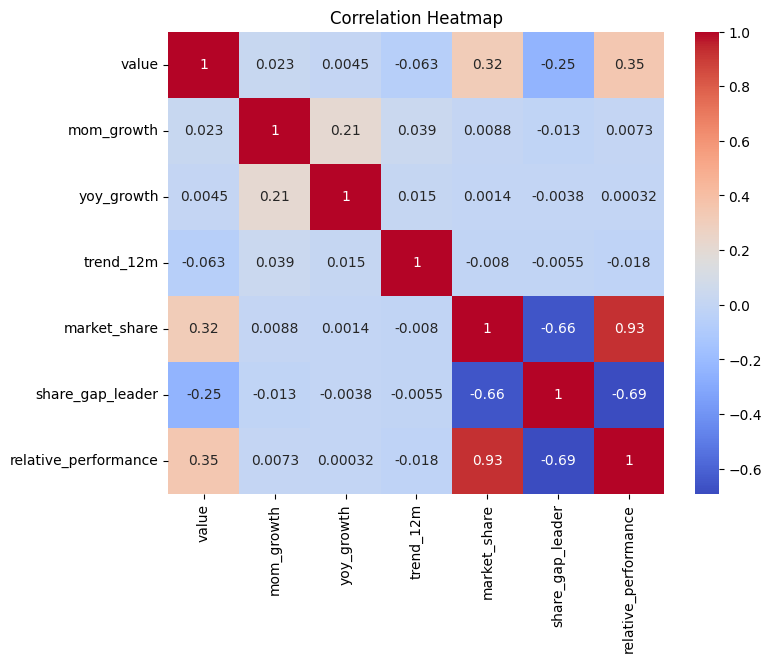

In [ ]:

# -----------------------------
#  CORRELATION ANALYSIS
# -----------------------------

# Correlation heatmap
key_feats = ['value', 'mom_growth', 'yoy_growth', 'trend_12m',
             'market_share', 'share_gap_leader', 'relative_performance']

plt.figure(figsize=(8,6))
sns.heatmap(df[key_feats].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
# Print top correlated pairs
corr_matrix = df[key_feats].corr().abs().unstack().sort_values(ascending=False)
corr_pairs = corr_matrix[(corr_matrix < 1)].head(5)
print("\nTop correlated feature pairs:\n", corr_pairs)


Top correlated feature pairs:
 relative_performance  market_share            0.926173
market_share          relative_performance    0.926173
relative_performance  share_gap_leader        0.691568
share_gap_leader      relative_performance    0.691568
                      market_share            0.657724
dtype: float64


In [ ]:
# -----------------------------
# BIVARIATE ANALYSIS
# -----------------------------


# Provider vs Circle Type
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='service_provider', y='value', hue='circle_type',
            estimator='sum', ci=None)
plt.title('Subscribers by Provider and Circle Type')
plt.xticks(rotation=45)
plt.show()


In [ ]:
# -----------------------------
#  CHURN TREND ANALYSIS
# -----------------------------


# Identify negative growth circles
neg_growth = df[df['mom_growth'] < 0].groupby('circle')['mom_growth'].mean().sort_values()
print("\nCircles with negative average MoM growth:\n", neg_growth.head(10))


Circles with negative average MoM growth:
 circle
Jharkhand              -0.096593
Himachal Pradesh       -0.080347
Jammu and Kashmir      -0.079743
Haryana                -0.077361
Uttar Pradesh (West)   -0.073451
Tamil Nadu             -0.072868
Bihar                  -0.072088
Madhya Pradesh         -0.071448
West Bengal            -0.071185
Arunachal Pradesh      -0.070856
Name: mom_growth, dtype: float64


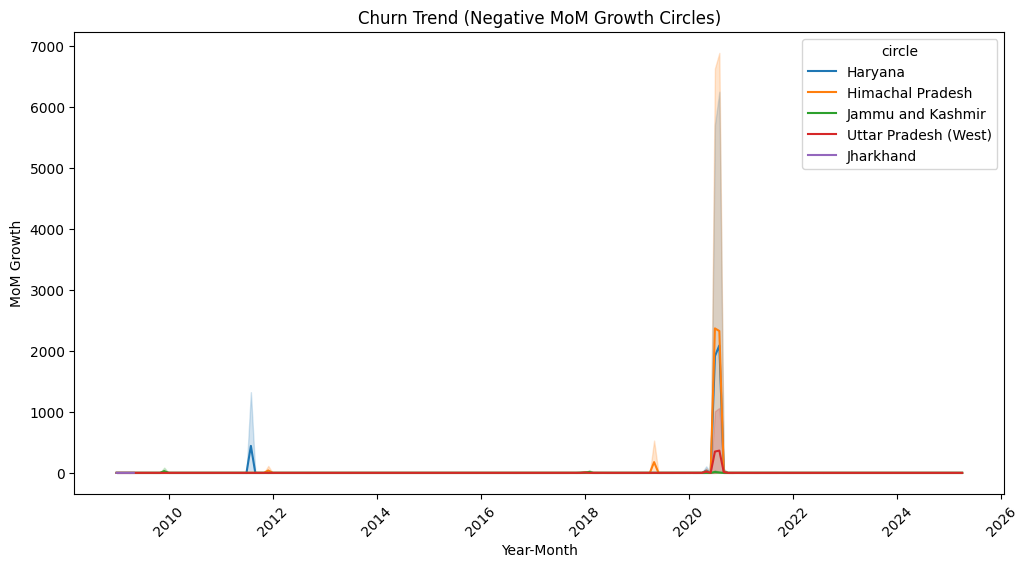

In [ ]:
# Top 5 churn circles
top_churn_circles = neg_growth.head(5).index.tolist()

# Filter for churn trend visualization
df_churn = df[df['circle'].isin(top_churn_circles)]

plt.figure(figsize=(12,6))
sns.lineplot(data=df_churn, x='year_month', y='mom_growth', hue='circle')
plt.title('Churn Trend (Negative MoM Growth Circles)')
plt.xlabel('Year-Month')
plt.ylabel('MoM Growth')
plt.xticks(rotation=45)
plt.show()

/tmp/ipython-input-3095494205.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mom_circle.index, y=mom_circle.values, palette=colors)


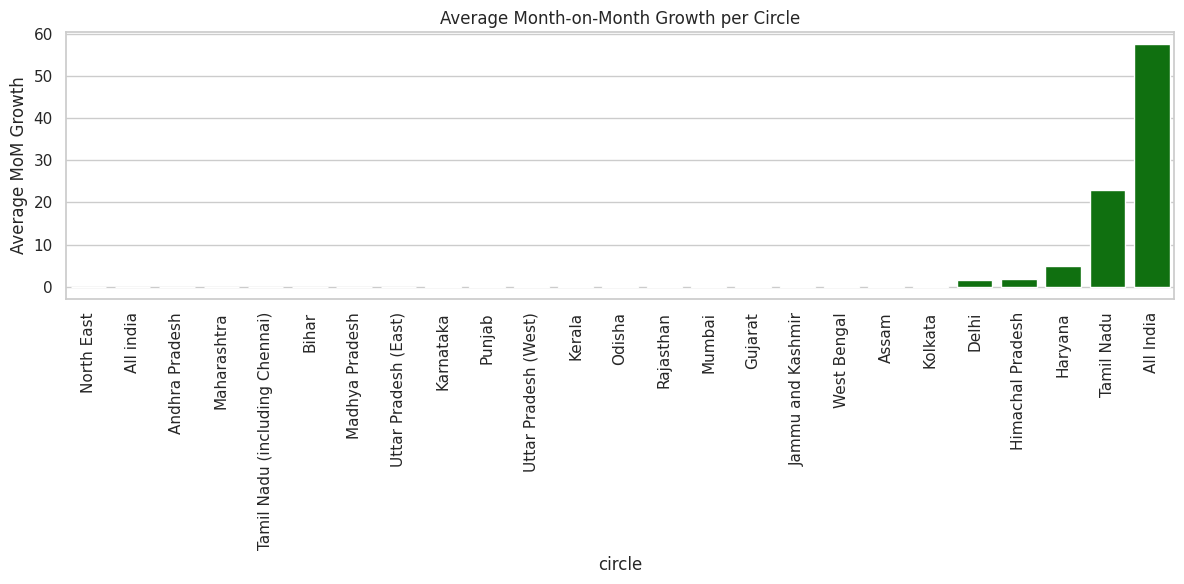

In [ ]:
# Compute average MoM growth per circle
mom_circle = df.groupby('circle')['mom_growth'].mean().sort_values()

# Color: red if negative, green if positive
colors = ['red' if x < 0 else 'green' for x in mom_circle]

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x=mom_circle.index, y=mom_circle.values, palette=colors)
plt.xticks(rotation=90)
plt.ylabel('Average MoM Growth')
plt.title('Average Month-on-Month Growth per Circle')
plt.tight_layout()
plt.show()

/tmp/ipython-input-1580442295.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_negative.values, y=top_negative.index, palette='Reds_r')


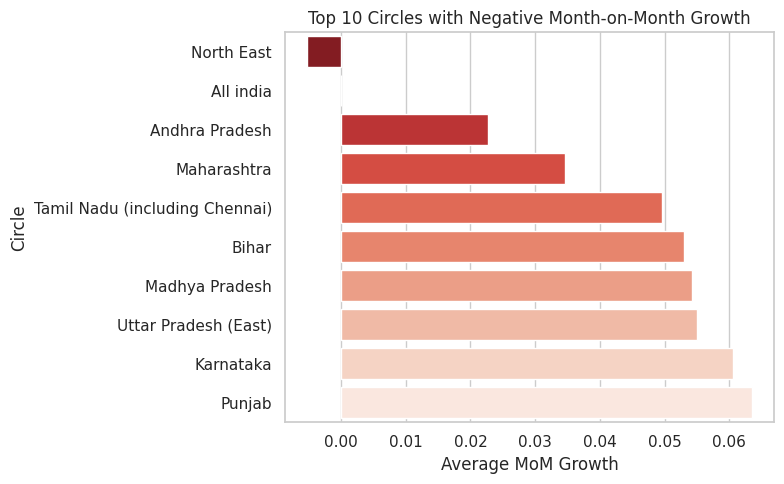

In [ ]:
# Top 10 circles with negative average MoM growth
top_negative = mom_circle.nsmallest(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top_negative.values, y=top_negative.index, palette='Reds_r')
plt.xlabel('Average MoM Growth')
plt.ylabel('Circle')
plt.title('Top 10 Circles with Negative Month-on-Month Growth')
plt.tight_layout()
plt.show()


In [ ]:
# Key Insights
# -----------------------
# Top providers by subscribers
top_ops = df.groupby('service_provider')['value'].sum().sort_values(ascending=False).head(10)
print("\nTop 10 Providers by Total Subscribers:\n", top_ops)

# Metro vs Non-Metro analysis
metro_summary = df.groupby('circle_type')['value'].sum()
print("\nTotal subscribers Metro vs Non-Metro:\n", metro_summary)

# Negative growth circles
neg_growth = df[df['mom_growth'] < 0].groupby('circle')['mom_growth'].mean().sort_values()
print("\nCircles with negative average MoM growth:\n", neg_growth.head(10))


Top 10 Providers by Total Subscribers:
 service_provider
Bharti Airtel                           9.023840e+10
Reliance Jio                            7.470626e+10
Vodafone Idea                           4.530547e+10
BSNL                                    4.381968e+10
Vodafone                                3.553582e+10
Idea                                    3.062888e+10
Reliance Communications                 2.401828e+10
Bharti Airtel (Including Tata Tele.)    1.539821e+10
Tata Teleservices                       1.462182e+10
Aircel                                  1.075863e+10
Name: value, dtype: float64

Total subscribers Metro vs Non-Metro:
 circle_type
Metro        2.214335e+10
Non-Metro    3.857253e+11
Name: value, dtype: float64

Circles with negative average MoM growth:
 circle
Jharkhand              -0.096593
Himachal Pradesh       -0.080347
Jammu and Kashmir      -0.079743
Haryana                -0.077361
Uttar Pradesh (West)   -0.073451
Tamil Nadu             -0.072868
Bih

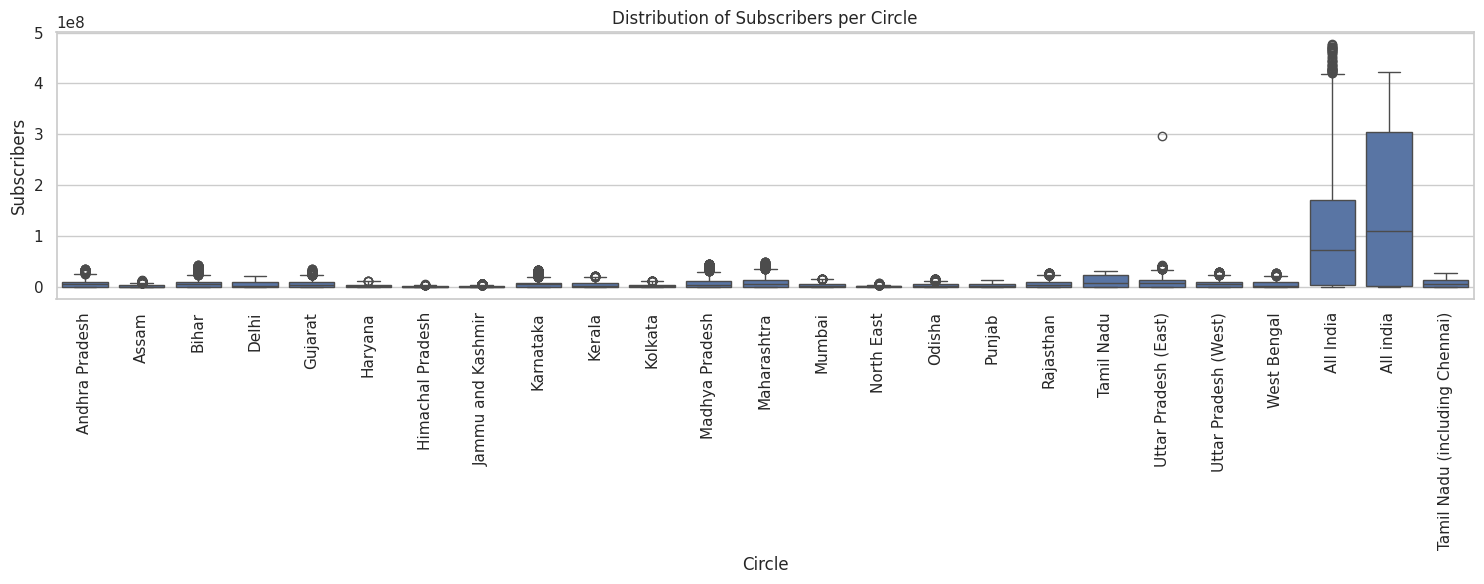

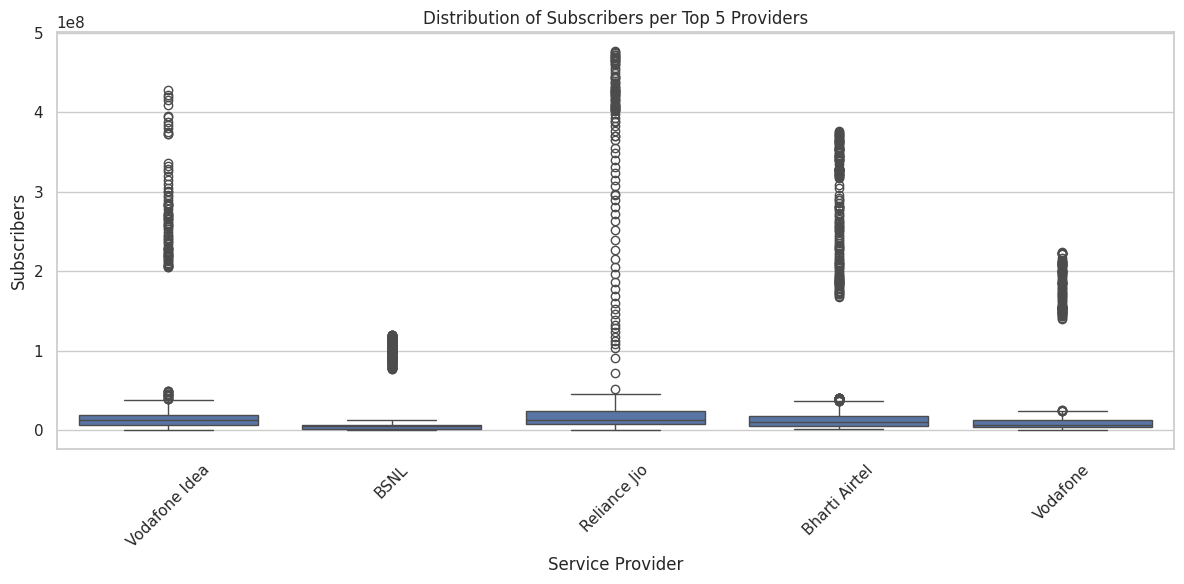

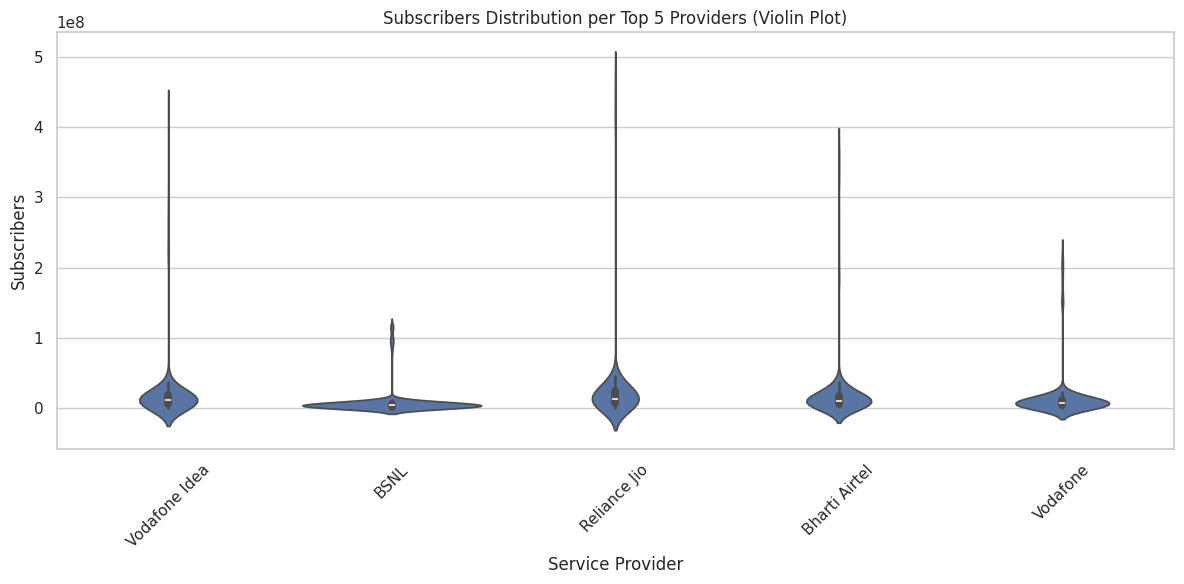

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure top 5 providers list exists
top_5_providers = df.groupby('service_provider')['value'].sum().sort_values(ascending=False).head(5).index.tolist()

# -------------------------------
# 1️⃣ Boxplot per Circle
# -------------------------------
plt.figure(figsize=(15,6))
sns.boxplot(data=df, x='circle', y='value')
plt.xticks(rotation=90)
plt.title('Distribution of Subscribers per Circle')
plt.xlabel('Circle')
plt.ylabel('Subscribers')
plt.tight_layout()
plt.savefig('boxplot_circle.png')  # Save figure for slides
plt.show()

# -------------------------------
# 2️⃣ Boxplot per Top Providers
# -------------------------------
plt.figure(figsize=(12,6))
sns.boxplot(data=df[df['service_provider'].isin(top_5_providers)],
            x='service_provider', y='value')
plt.xticks(rotation=45)
plt.title('Distribution of Subscribers per Top 5 Providers')
plt.xlabel('Service Provider')
plt.ylabel('Subscribers')
plt.tight_layout()
plt.savefig('boxplot_top5_providers.png')
plt.show()

# -------------------------------
# 3️⃣ Violin Plot per Top Providers
# -------------------------------
plt.figure(figsize=(12,6))
sns.violinplot(data=df[df['service_provider'].isin(top_5_providers)],
               x='service_provider', y='value')
plt.xticks(rotation=45)
plt.title('Subscribers Distribution per Top 5 Providers (Violin Plot)')
plt.xlabel('Service Provider')
plt.ylabel('Subscribers')
plt.tight_layout()
plt.savefig('violin_top5_providers.png')
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
try:
    from IPython.display import display
except ImportError:
    display = print



📘 Logistic Regression Parameters:
{'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 1000, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}

📊 Logistic Regression Performance:
Accuracy: 0.897
Precision: 0.79
Recall: 0.893
F1 Score: 0.839
ROC-AUC: 0.961

Confusion Matrix:
 [[7338  829]
 [ 373 3127]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.90      0.92      8167
           1       0.79      0.89      0.84      3500

    accuracy                           0.90     11667
   macro avg       0.87      0.90      0.88     11667
weighted avg       0.90      0.90      0.90     11667


🌲 Random Forest Parameters:
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'max_leaf_nodes': No

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import os
paths = ["Cleaned_Telecom_Subscriptions.csv", "notebooks/Cleaned_Telecom_Subscriptions.csv", "../data/Cleaned_Telecom_Subscriptions.csv", "data/Cleaned_Telecom_Subscriptions.csv"]
for path in paths:
    if os.path.exists(path):
        data = pd.read_csv(path)
        break


C:\Users\RITESH\AppData\Local\Temp\ipykernel_9956\4024873498.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("Cleaned_Telecom_Subscriptions.csv")


In [ ]:
print("Dataset shape:", data.shape)
display(data.head())

Dataset shape: (70728, 8)


,year,month,circle,type_of_connection,service_provider,value,unit,notes
0,2025,April,Andhra Pradesh,wireless,Bharti Airtel (Including Tata Tele.),33965795,value in absolute number,NaN
1,2025,April,Assam,wireless,Bharti Airtel (Including Tata Tele.),12314102,value in absolute number,NaN
2,2025,April,Bihar,wireless,Bharti Airtel (Including Tata Tele.),40967773,value in absolute number,NaN
3,2025,April,Delhi,wireless,Bharti Airtel (Including Tata Tele.),18877637,value in absolute number,NaN
4,2025,April,Gujarat,wireless,Bharti Airtel (Including Tata Tele.),12401101,value in absolute number,NaN


In [ ]:
cat_cols = data.select_dtypes(include=['object']).columns

le = LabelEncoder()
for col in cat_cols:
    data[col] = le.fit_transform(data[col].astype(str))

print("\nMissing values per column:")
print(data.isnull().sum())

data.fillna(data.median(), inplace=True)


Missing values per column:
year                  0
month                 0
circle                0
type_of_connection    0
service_provider      0
value                 0
unit                  0
notes                 0
dtype: int64


In [ ]:
target_col = 'circle'  
if target_col not in data.columns:
    raise ValueError(f"The column '{target_col}' is not found. Please update 'target_col' to your target variable name.")

X = data.drop(columns=[target_col])
y = data[target_col]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

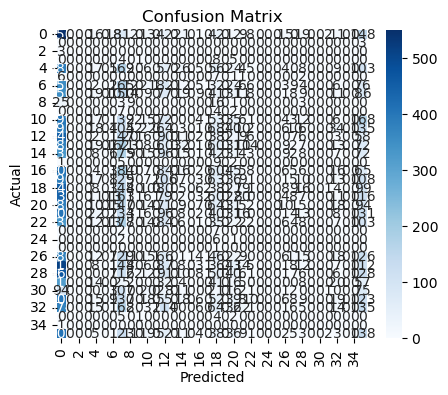

In [ ]:
plt.figure(figsize=(5,4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

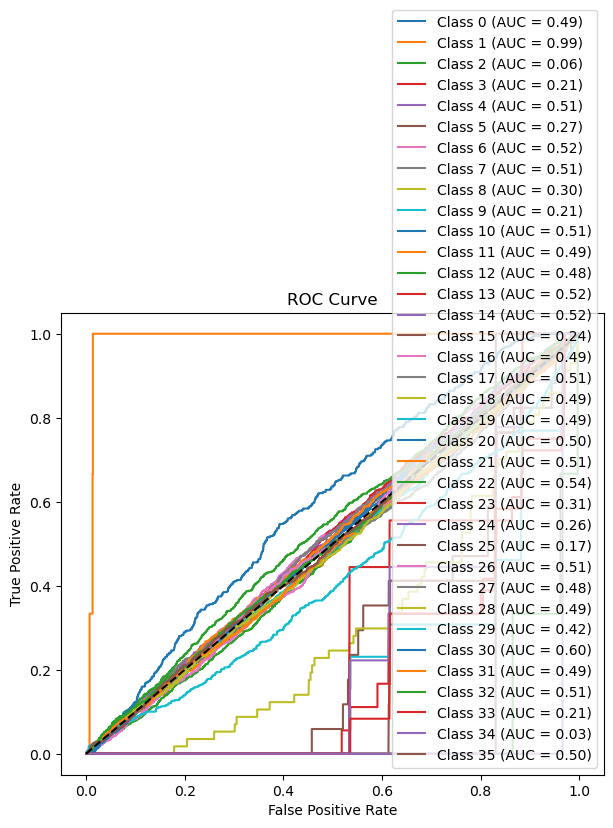

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

n_classes = len(np.unique(y_test))

plt.figure(figsize=(7, 6))

if n_classes == 2:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_val:.2f})")

else:
    y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
    
    if y_proba.ndim == 1:  # If model returned 1D probabilities
        y_proba_bin = np.tile(y_proba.reshape(-1, 1), (1, n_classes))
    else:
        y_proba_bin = y_proba

    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_bin[:, i])
        roc_auc_i = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc_i:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.06      0.54      0.11      1020
           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00        18
           4       0.06      0.02      0.03       885
           5       0.00      0.00      0.00        17
           6       0.01      0.00      0.00       824
           7       0.04      0.17      0.07       863
           9       0.05      0.16      0.07        57
          10       0.00      0.00      0.00        13
          11       0.06      0.02      0.02       940
          12       0.00      0.00      0.00       927
          13       0.05      0.10      0.07       872
          14       0.00      0.00      0.00       931
          15       0.06      0.02      0.03       838
          16       0.00      0.00      0.00        17
          17       0.02      0.00      0.00       929
   

E:\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
E:\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
E:\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=5),
        "KNN": KNeighborsClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"\n{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))



Logistic Regression Accuracy: 0.0523
              precision    recall  f1-score   support

           0       0.06      0.54      0.11      1020
           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00        18
           4       0.06      0.02      0.03       885
           5       0.00      0.00      0.00        17
           6       0.01      0.00      0.00       824
           7       0.04      0.17      0.07       863
           9       0.05      0.16      0.07        57
          10       0.00      0.00      0.00        13
          11       0.06      0.02      0.02       940
          12       0.00      0.00      0.00       927
          13       0.05      0.10      0.07       872
          14       0.00      0.00      0.00       931
          15       0.06      0.02      0.03       838
          16       0.00      0.00      0.00        17
          17       0.02      0.00      0.00

E:\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
E:\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
E:\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))



Decision Tree Accuracy: 0.3373
              precision    recall  f1-score   support

           0       0.42      0.46      0.44      1020
           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00        18
           4       0.09      0.34      0.14       885
           5       0.00      0.00      0.00        17
           6       0.13      0.29      0.18       824
           7       0.26      0.30      0.28       863
           8       0.00      0.00      0.00         0
           9       0.37      0.26      0.31        57
          10       0.08      0.08      0.08        13
          11       0.36      0.41      0.39       940
          12       0.39      0.36      0.37       927
          13       0.39      0.35      0.37       872
          14       0.43      0.35      0.39       931
          15       0.34      0.25      0.29       838
          16       0.25      0.06      0.10      

E:\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
E:\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
E:\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
E:\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Recall 


Random Forest Accuracy: 0.1927
              precision    recall  f1-score   support

           0       0.31      0.32      0.32      1020
           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00        18
           4       0.19      0.22      0.20       885
           5       0.00      0.00      0.00        17
           6       0.17      0.17      0.17       824
           7       0.16      0.16      0.16       863
           8       0.00      0.00      0.00         0
           9       0.15      0.12      0.13        57
          10       0.00      0.00      0.00        13
          11       0.28      0.28      0.28       940
          12       0.16      0.17      0.17       927
          13       0.18      0.19      0.19       872
          14       0.21      0.20      0.21       931
          15       0.15      0.14      0.14       838
          16       0.00      0.00      0.00      

E:\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
E:\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
E:\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
E:\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Recall 

In [ ]:
result_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy']).sort_values(by='Accuracy', ascending=False)
print("\nModel Comparison:\n", result_df)


Model Comparison:
                  Model  Accuracy
1        Decision Tree  0.337339
2        Random Forest  0.192658
0  Logistic Regression  0.052264


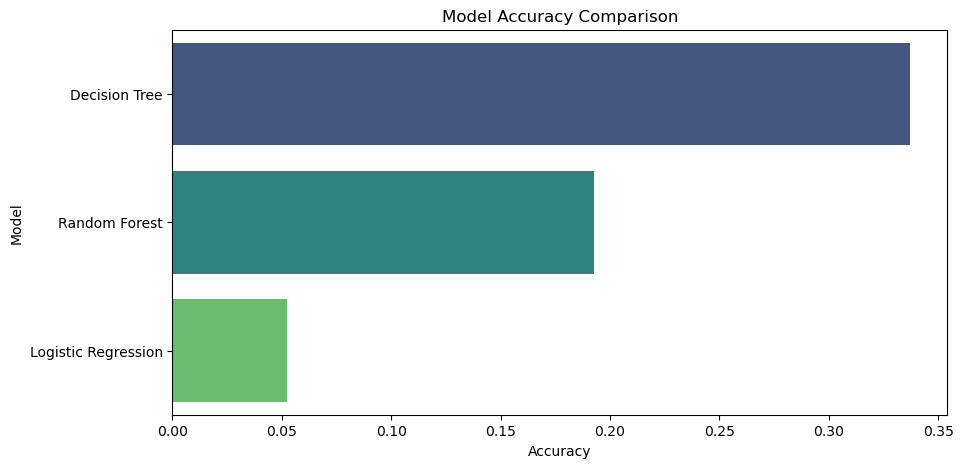

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x='Accuracy', y='Model', data=result_df, palette='viridis')
plt.title("Model Accuracy Comparison")
plt.show()

In [ ]:
best_model_name = result_df.iloc[0]['Model']
best_model = models[best_model_name]
print(f"\n Best Model: {best_model_name} with Accuracy = {result_df.iloc[0]['Accuracy']:.4f}")


 Best Model: Decision Tree with Accuracy = 0.3373


In [ ]:
import joblib
joblib.dump(best_model, f"best_model_{best_model_name.replace(' ', '_')}.pkl")
print(f"Model saved as best_model_{best_model_name.replace(' ', '_')}.pkl")

Model saved as best_model_Decision_Tree.pkl


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=5),
        "KNN": KNeighborsClassifier()
}

evaluation = []

for name, model in models.items():
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    auc = np.nan
    if hasattr(model, "predict_proba"):
        try:
            y_proba = model.predict_proba(X_test)
            if len(np.unique(y_test)) == 2:
                auc = roc_auc_score(y_test, y_proba[:, 1])
            elif len(np.unique(y_test)) > 2:
                auc = roc_auc_score(y_test, y_proba, multi_class='ovr')
        except Exception:
            auc = np.nan 

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    evaluation.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'AUC': auc
    })


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
import pandas as pd

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=5),
        "KNN": KNeighborsClassifier()
}

evaluation = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    auc = np.nan
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)
        try:
            if len(np.unique(y_test)) == 2:
                auc = roc_auc_score(y_test, y_proba[:, 1])
            else:
                if y_proba.shape[1] == len(np.unique(y_test)):
                    auc = roc_auc_score(y_test, y_proba, multi_class='ovr')
        except ValueError:
            auc = np.nan

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    evaluation.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'AUC': auc
    })
    
eval_df = pd.DataFrame(evaluation).sort_values(by='Accuracy', ascending=False)
display(eval_df)


In [ ]:
best_model_name = eval_df.iloc[0]['Model']
print("best Model Selected:", best_model_name)